<a href="https://colab.research.google.com/github/sanjushajii/Assignments/blob/main/CVision_imgresize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

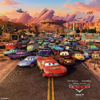

In [ ]:
#resizing.py
from PIL import Image

#open image in jpg
image = Image.open('/content/drive/MyDrive/Colab Notebooks/Cars_2006.jpg')

#resize
resized_image = image.resize((100, 100))

#display
resized_image.show()

display(resized_image)

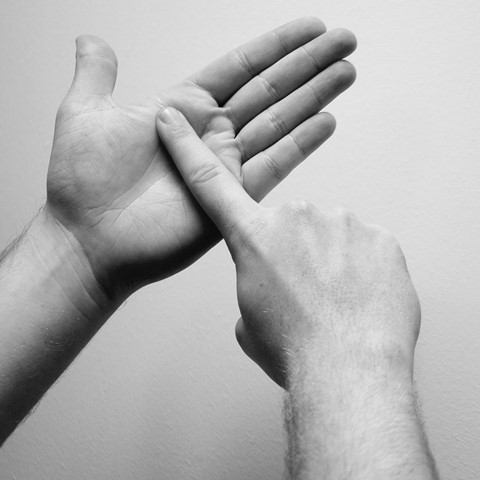

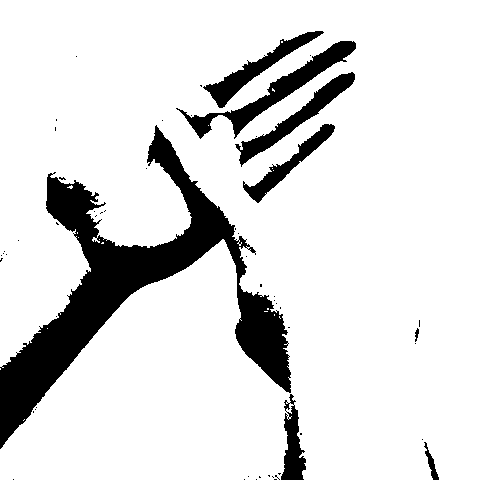

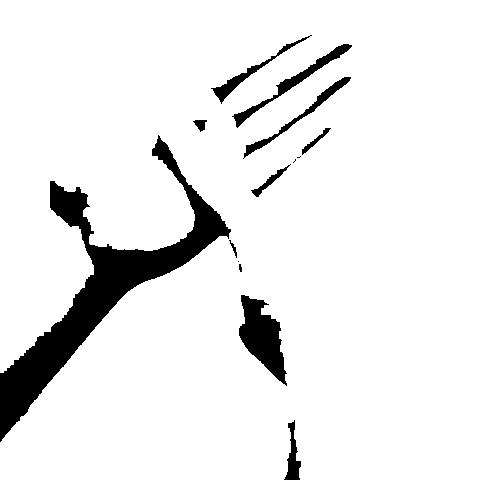

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
image = cv2.imread('/content/drive/MyDrive/british-sign-language-level-1.jpg',0)

if image is None:
  print("Error could not open or read the image file")
  exit()

_, binary_image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
kernel = np.ones ((3,3), np.uint8)

dilated_image = cv2.dilate(binary_image, kernel, iterations=3)
cv2_imshow(image)
cv2_imshow(binary_image)
cv2_imshow(dilated_image)


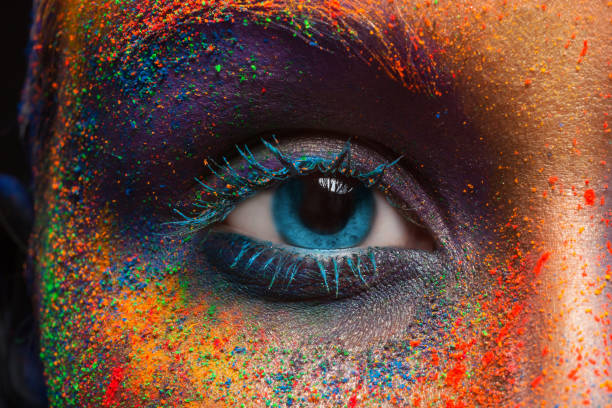

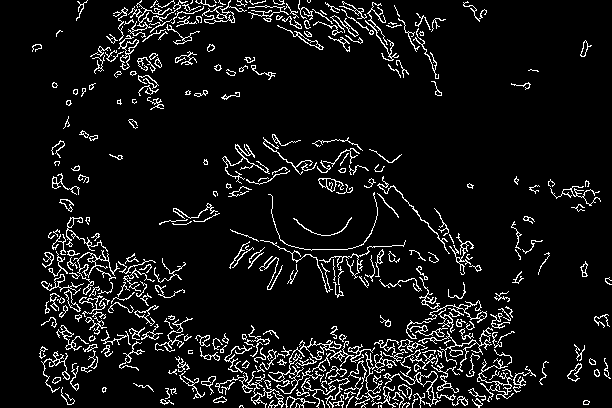

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
image = cv2.imread('/content/drive/MyDrive/istockphoto-814423752-612x612.jpg',0)

if image is None:
  print("Error: Imaage not found")
else:
  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  blurred_image = cv2.GaussianBlur(gray_image, (5,5), 1.4)
  edges = cv2.Canny(blurred_image,threshold1=50, threshold2=150)

  cv2_imshow(image)
  cv2_imshow(edges)

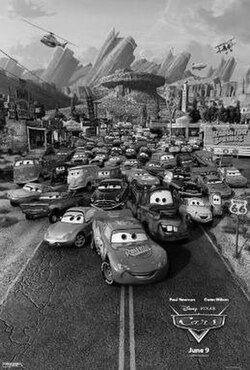

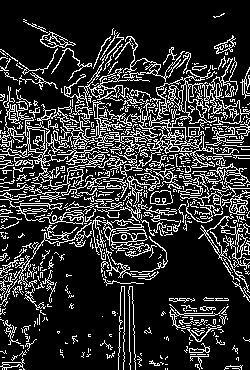

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
image = cv2.imread('/content/drive/MyDrive/Colab Notebooks/Cars_2006.jpg',0)

edges = cv2.Canny(image, 100, 200)

cv2_imshow(image)
cv2_imshow(edges)

<function matplotlib.pyplot.show(close=None, block=None)>

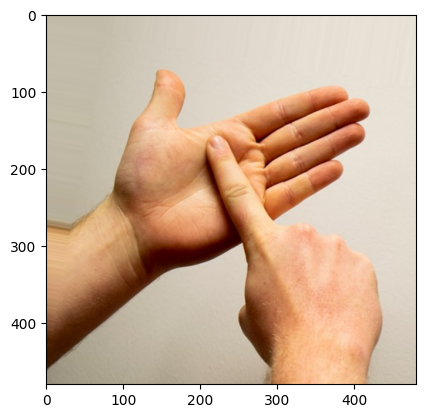

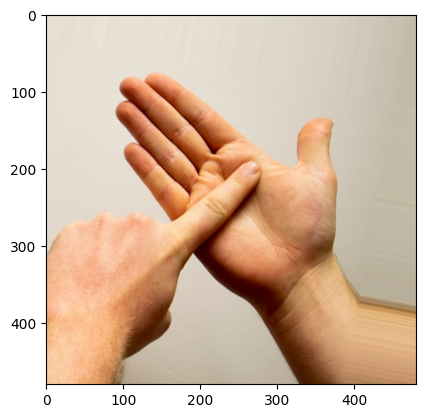

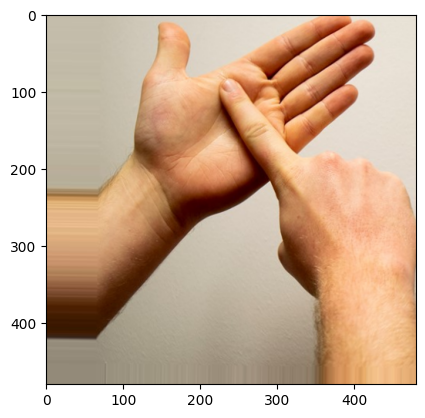

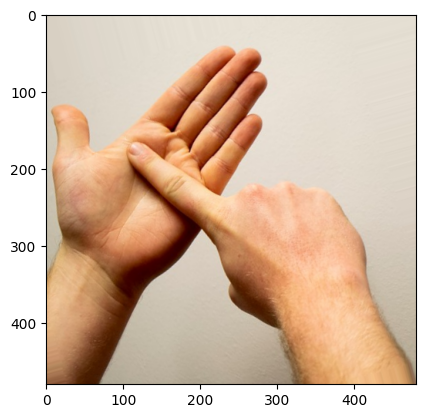

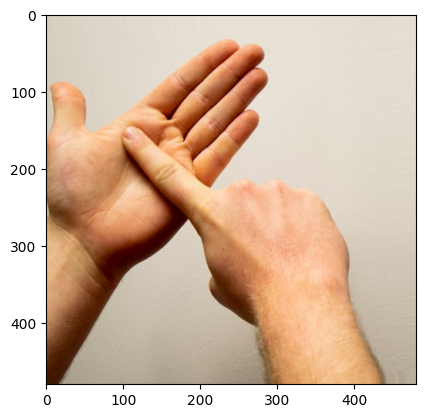

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
save_dir = 'augmented_images'
if not os.path.exists(save_dir):
  os.makedirs(save_dir)

image_gen = ImageDataGenerator(rotation_range=20,
                               width_shift_range=0.2,
                               height_shift_range=0.2,
                               horizontal_flip=True)
img = load_img('/content/drive/MyDrive/british-sign-language-level-1.jpg')

x = img_to_array(img)
x = np.expand_dims(x,axis=0)

i=0
for batch in image_gen.flow(x, batch_size=1, save_to_dir=save_dir, save_prefix='aug', save_format='jpg'):
  plt.figure(i)
  imgplot = plt.imshow(batch[0].astype('uint8'))
  i += 1
  if i % 5==0:
      break
plt.show


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
save_dir = 'augmented_images'
if not os.path.exists(save_dir):
  os.makedirs(save_dir)

image_gen = ImageDataGenerator(
    rotation_range=30,           # Increased rotation
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,            # Added shearing
    zoom_range=0.2,              # Added zooming
    horizontal_flip=True,
    brightness_range=[0.8, 1.2], # Added brightness variation
    fill_mode='nearest'          # Strategy for filling newly created pixels
)

img = load_img('/content/drive/MyDrive/british-sign-language-level-1.jpg')

x = img_to_array(img)
x = np.expand_dims(x,axis=0)

i=0
for batch in image_gen.flow(x, batch_size=1, save_to_dir=save_dir, save_prefix='aug', save_format='jpg'):
  plt.figure(i)
  imgplot = plt.imshow(batch[0].astype('uint8'))
  i += 1
  if i % 50==0:
      break
plt.show

In [ ]:
import os
from PIL import Image
import numpy as np
import cv2
import concurrent.futures
#Define the input and output folders
image_folder = '/content/drive/MyDrive/Colab Notebooks' # Replace with the path to your images
output_folder = '/content/drive/MyDrive/Colab Notebooks' # Replace with the path to save processed imges
# Ensure the output exists
os.makedirs(output_folder, exist_ok=True)
def process_image(filename):
  try:
    # Define the full path for euch image
    image_path = os.path.join(image_folder, filename)
    # Load the image
    analog_image = Image.open(image_path)
    # Convert to grayscale
    gray_image = analog_image.convert('L')
    # Convert to Numpy array for OpenCV processing
    gray_array = np.array(gray_image)
    # Apply binary threshold
    _, binary_array = cv2.threshold(gray_array, 128, 255, cv2.THRESH_BINARY)
    # Save the processed image directly to the output folder
    output_path = os.path.join(output_folder, filename)
    cv2.imwrite(output_path, binary_image)
    print(f"processed and saved: {filename}")
  except Exception as e:
    # Handle any issues (file format, corruption, etc.)
    print(f"Error processing {filename}: {e}")
# Use ThreadPoolExecutor to process images in parallel
with concurrent.futures.ThreadPoolExecutor() as executor:
  # Get a list of valid image files(adjust extension if needed)
  image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg') or f.endswith('.png')]
  # Process euch image file in parallel
  executor.map(process_image, image_files)

Error processing istockphoto-814423752-612x612.jpg: name 'binary_image' is not defined
Error processing Cars_2006.jpg: name 'binary_image' is not defined


In [ ]:
import pandas as pd

file_path = r"/train_test_network.csv"
df = pd.read_csv(file_path)

print("✅ Loaded:", df.shape)
print("Columns:", df.columns.tolist())

# ---- STEP 1: detect label column ----
possible_labels = ['label', 'Label', 'attack', 'Attack', 'class', 'Class', 'type', 'Type', 'target', 'Target']

label_col = None
for col in possible_labels:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    raise ValueError("❌ No label column found. Please check the printed column names above.")

print(f"✅ Label column detected: {label_col}")

# ---- STEP 2: rename to standard name ----
df.rename(columns={label_col: 'label'}, inplace=True)

# ---- STEP 3: make label readable for Tableau ----
# If labels are numeric (0/1), convert to Normal/Attack
if df['label'].dtype != 'object':
    df['label'] = df['label'].map({0: 'Normal', 1: 'Attack'}).fillna(df['label'])

# ---- STEP 4: remove obvious ID/time columns (optional but safe) ----
drop_cols = ['id', 'ID', 'timestamp', 'Timestamp', 'time', 'Time', 'flow_id', 'Flow_ID']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# ---- STEP 5: save Tableau-ready file ----
output_path = r"C:\Users\lali\Downloads\train_test_network_tableau.csv"
df.to_csv(output_path, index=False)

print("✅ Tableau-ready file saved at:")
print()


In [ ]:
import pandas as pd

file_path = r"C:\Users\lali\Downloads\train_test_network.csv"
df = pd.read_csv(file_path)

print("✅ Loaded:", df.shape)
print("Columns:", df.columns.tolist())

possible_labels = ['label','Label','attack','Attack','class','Class','type','Type','target','Target']

label_col = None
for col in possible_labels:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    raise ValueError("No label column found")

df.rename(columns={label_col: 'label'}, inplace=True)

if df['label'].dtype != 'object':
    df['label'] = df['label'].map({0:'Normal',1:'Attack'})

drop_cols = ['id','timestamp','time','flow_id']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

output_path = r"C:\Users\lali\Downloads\train_test_network_tableau.csv"
df.to_csv(output_path, index=False)

import pandas as pd

file_path = r"C:\Users\lali\Downloads\train_test_network.csv"
df = pd.read_csv(file_path)

print("✅ Loaded:", df.shape)
print("Columns:", df.columns.tolist())

# ---- STEP 1: detect label column ----
possible_labels = ['label', 'Label', 'attack', 'Attack', 'class', 'Class', 'type', 'Type', 'target', 'Target']

label_col = None
for col in possible_labels:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    raise ValueError("❌ No label column found. Please check the printed column names above.")

print(f"✅ Label column detected: {label_col}")

# ---- STEP 2: rename to standard name ----
df.rename(columns={label_col: 'label'}, inplace=True)

# ---- STEP 3: make label readable for Tableau ----
# If labels are numeric (0/1), convert to Normal/Attack
if df['label'].dtype != 'object':
    df['label'] = df['label'].map({0: 'Normal', 1: 'Attack'}).fillna(df['label'])

# ---- STEP 4: remove obvious ID/time columns (optional but safe) ----
drop_cols = ['id', 'ID', 'timestamp', 'Timestamp', 'time', 'Time', 'flow_id', 'Flow_ID']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# ---- STEP 5: save Tableau-ready file ----
output_path = r"C:\Users\lali\Downloads\train_test_network_tableau.csv"
df.to_csv(output_path, index=False)

print("✅ Tableau-ready file saved at:")
print(output_path)



In [ ]:
# =========================
# DATASET PREPARATION
# =========================

import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

IMG_SIZE = 128

# Dataset Paths
train_img_path = "/content/dataset/train/images"
train_mask_path = "/content/dataset/train/masks"

test_img_path = "/content/dataset/test/images"
test_mask_path = "/content/dataset/test/masks"


# Function to Load Images and Masks
def load_data(image_path, mask_path):

    images = []
    masks = []

    files = os.listdir(image_path)

    for file in files:

        # Read image
        img = cv2.imread(os.path.join(image_path, file))
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        # Read mask
        mask = cv2.imread(os.path.join(mask_path, file), 0)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)


# Load Train and Test Data
X_train, Y_train = load_data(train_img_path, train_mask_path)

X_test, Y_test = load_data(test_img_path, test_mask_path)


# Create Validation Set
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.15,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Validation Data:", X_val.shape)
print("Testing Data:", X_test.shape)